# 06 — Resultados finais e conclusão

Este notebook consolida os achados de `01` a `05` em uma conclusão única. Não introduz dados novos — apenas reúne e interpreta o que já foi calculado, deixando explícito o que é conclusão sustentada pelos dados e o que é limitação declarada.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import models as m

plt.rcParams["figure.dpi"] = 110
cores = {"conservador": "#c44e52", "experimental": "#4c72b0", "otimista": "#55a868"}

## 1. Resultado experimental (o que foi realmente medido)

- 250 mL de soro de leite cru → 15 mL de destilado inflamável (rendimento de 6,0% v/v, ou 60 mL de destilado por litro de soro).
- Três evidências independentes (temperatura de coleta ≈78 °C, combustão positiva, chama sem coloração visível) confirmam **qualitativamente** que o destilado contém etanol.
- **A concentração de etanol no destilado nunca foi medida** — essa é a lacuna central de todo o restante da análise.

## 2. Potencial técnico (modelo, notebook 03)

Usando a faixa de teor alcoólico que o próprio projeto já esperava (5–12% v/v, premissa declarada, não medição), o processo produziria entre **3,0 e 7,2 mL de etanol puro por litro de soro** — o que representa apenas **9% a 22% do rendimento teórico estequiométrico** da lactose disponível (0,538 g etanol/g lactose).


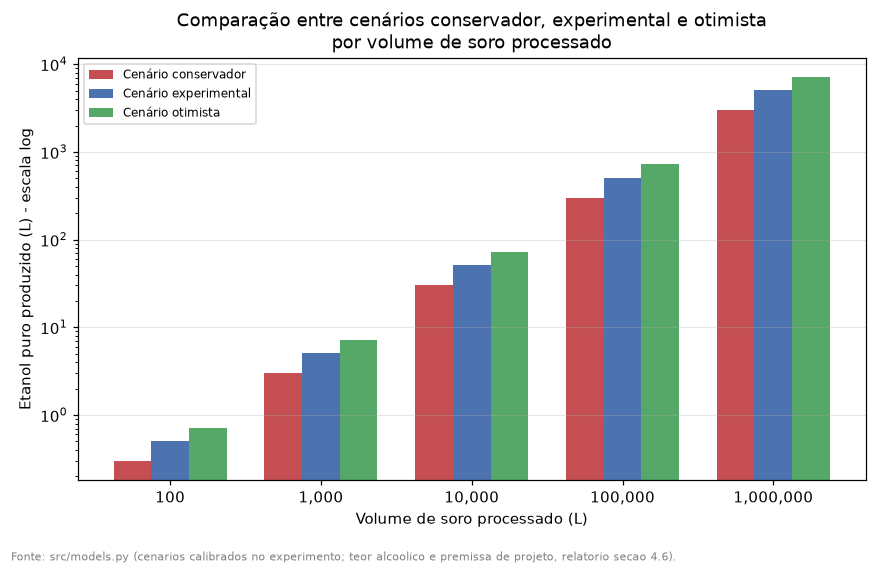

In [2]:
volumes_L = [100, 1_000, 10_000, 100_000, 1_000_000]
escala = m.scale_all_scenarios(volumes_L)

fig, ax = plt.subplots(figsize=(8, 5))
largura = 0.25
x = range(len(volumes_L))
for i, cenario in enumerate(m.SCENARIOS):
    sub = escala[escala["cenario"] == cenario].sort_values("soro_L")
    ax.bar([xi + i*largura for xi in x], sub["etanol_puro_L"], width=largura,
           label=f"Cenário {cenario}", color=cores[cenario])

ax.set_xticks([xi + largura for xi in x])
ax.set_xticklabels([f"{v:,}" for v in volumes_L])
ax.set_yscale("log")
ax.set_xlabel("Volume de soro processado (L)")
ax.set_ylabel("Etanol puro produzido (L) - escala log")
ax.set_title("Comparação entre cenários conservador, experimental e otimista\npor volume de soro processado")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
fig.text(0.01, -0.03,
         "Fonte: src/models.py (cenarios calibrados no experimento; teor alcoolico e premissa de projeto, relatorio secao 4.6).",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/fig_comparacao_cenarios.png", dpi=150, bbox_inches="tight")
plt.show()

A diferença entre os cenários é de 2,4× (razão entre 12% e 5% de teor alcoólico) — inteiramente proveniente da incerteza sobre a densidade do destilado, não de qualquer outro parâmetro do modelo técnico. **Essa é a lacuna experimental cuja resolução mais mudaria a precisão de todo o resto da análise.**

## 3. Potencial econômico (modelo, notebook 04) e o que a sensibilidade revela (notebook 05)

Ao preço de varejo dos reagentes usados no experimento e ao preço de mercado do etanol (CEPEA/Esalq), o resultado operacional é fortemente negativo em todas as escalas testadas — mas essa conclusão **não pode ser atribuída com confiança** só ao preço de insumo, porque:

- O preço de lactase/fermento usado é de **varejo/farmácia**, não industrial — não encontramos fonte confiável de preço industrial (lacuna declarada, notebook 02).
- **O achado mais robusto não depende desse preço de varejo**: mesmo isolando apenas o custo de **energia térmica** (calculado por física — calor específico e calor latente — não por preço de mercado de insumo) contra a receita ao preço real do etanol, o custo de energia sozinho já é ~4,8× maior que a receita. Seria necessário um teor alcoólico de **~41% v/v** só para cobrir a energia do processo — bem acima da faixa de 5–12% que o próprio projeto espera antes de qualquer retificação.
- Isso aponta para uma causa estrutural: o processo, como caracterizado no experimento, produz uma solução **muito diluída**. O custo de aquecer/destilar escala com o volume total processado (majoritariamente água); a receita escala com o teor alcoólico, que é baixo.


## 4. Proveniência dos dados usados no modelo

Para deixar essa rastreabilidade explícita, eis a origem de cada parâmetro central do modelo:


In [3]:
proveniencia = pd.DataFrame([
    {"parametro": "Recuperação na filtração (64%)", "tipo": "Medido", "origem": "Experimento (notebook 01)"},
    {"parametro": "Razão destilado/mosto (9,4%)", "tipo": "Medido", "origem": "Experimento (notebook 01)"},
    {"parametro": "Teor alcoólico do destilado (5-12%)", "tipo": "Premissa de projeto", "origem": "Relatório, seção 4.6 (não medido)"},
    {"parametro": "Concentração de lactose no soro (~49 g/L)", "tipo": "Externo (proxy)", "origem": "EPAMIG/ILCT, E03 (não é medição do nosso soro)"},
    {"parametro": "Rendimento teórico estequiométrico (0,538 g/g)", "tipo": "Calculado", "origem": "Estequiometria própria (E07)"},
    {"parametro": "Eficiência industrial de fermentação (80-97%)", "tipo": "Externo (literatura)", "origem": "Kluyveromyces spp., E08/E09 - rota biológica diferente"},
    {"parametro": "Preço do etanol (R$ 2,64/L)", "tipo": "Externo", "origem": "CEPEA/Esalq, E12 (set/2026)"},
    {"parametro": "Tarifa de energia industrial", "tipo": "Externo", "origem": "CEMIG Grupo A4, E16"},
    {"parametro": "Energia térmica do processo", "tipo": "Calculado", "origem": "Física (calor específico + calor latente)"},
    {"parametro": "Preço de lactase e fermento", "tipo": "Medido (mas VAREJO)", "origem": "Relatório, seção 3.6 - proxy fraco para preço industrial"},
])
proveniencia

,parametro,tipo,origem
0,Recuperação na filtração (64%),Medido,Experimento (notebook 01)
1,"Razão destilado/mosto (9,4%)",Medido,Experimento (notebook 01)
2,Teor alcoólico do destilado (5-12%),Premissa de projeto,"Relatório, seção 4.6 (não medido)"
3,Concentração de lactose no soro (~49 g/L),Externo (proxy),"EPAMIG/ILCT, E03 (não é medição do nosso soro)"
4,"Rendimento teórico estequiométrico (0,538 g/g)",Calculado,Estequiometria própria (E07)
5,Eficiência industrial de fermentação (80-97%),Externo (literatura),"Kluyveromyces spp., E08/E09 - rota biológica d..."
6,"Preço do etanol (R$ 2,64/L)",Externo,"CEPEA/Esalq, E12 (set/2026)"
7,Tarifa de energia industrial,Externo,"CEMIG Grupo A4, E16"
8,Energia térmica do processo,Calculado,Física (calor específico + calor latente)
9,Preço de lactase e fermento,Medido (mas VAREJO),"Relatório, seção 3.6 - proxy fraco para preço ..."


## 5. Limitações do estudo (consolidadas)

1. **Densidade/teor alcoólico do destilado nunca foi medido** — é a lacuna mais impactante de todo o modelo técnico.
2. **Concentração de lactose do soro específico usado no experimento nunca foi medida** — usamos um proxy de literatura.
3. **Não há dado confiável de preço industrial de enzima/levedura** — usamos preço de varejo, provavelmente uma superestimativa.
4. **O modelo econômico não inclui CAPEX, custo do soro, mão de obra nem retificação** — é um modelo de custo variável apenas.
5. **A rota biológica usada no experimento (lactase + *Saccharomyces cerevisiae*) tem menos precedente direto na literatura consultada** do que a rota alternativa com *Kluyveromyces* (que fermenta lactose diretamente) — as comparações de eficiência de literatura são indicativas, não equivalentes.
6. **Execução única, sem réplicas, sem ensaio controle, sem monitoramento cinético da fermentação** — limita qualquer afirmação sobre reprodutibilidade.
7. O artigo mais diretamente comparável (Sansonetti et al. 2009, etanol de soro de ricota) não pôde ser acessado — citado como referência, não usado numericamente.

## 6. Conclusão

**O que os dados sustentam:**
- A rota química (desproteinização → hidrólise enzimática → fermentação → destilação fracionada) **funciona**: produz um destilado inflamável a partir de um resíduo agroindustrial, com evidências convergentes de que se trata de etanol.
- Em escala, **mantendo as mesmas eficiências de processo**, a produção de etanol escala linearmente com o volume de soro — mas essa é uma extrapolação simples, não uma previsão de desempenho industrial real (eficiências de filtração, fermentação e destilação industriais não foram verificadas).
- Nas condições de preço testadas, o processo está **muito distante do equilíbrio econômico** — e essa distância é grande o suficiente para se manter mesmo sob a incerteza mais favorável de preço de insumo, porque o próprio custo de energia (calculado, não estimado de mercado) já supera a receita.

**O que os dados NÃO sustentam:**
- Uma afirmação definitiva de viabilidade ou inviabilidade econômica industrial — falta o preço real de insumo em escala e falta saber se a concentração de etanol pode ser aumentada com otimização de processo (menos diluição).
- Uma comparação direta e rigorosa com a literatura de fermentação de soro de leite — a rota biológica usada é diferente da mais estudada na literatura encontrada.
- Qualquer estimativa de retorno sobre investimento — não há dado de CAPEX.

**Próximos passos que mudariam mais a qualidade desta análise, em ordem de impacto:**
1. Medir a densidade do destilado (resolve a maior incerteza do modelo técnico).
2. Buscar preço industrial real de lactase e levedura a granel (resolve a maior incerteza do modelo econômico "de varejo").
3. Testar formas de aumentar a concentração final de etanol (menos diluição) — é a alavanca mais promissora indicada pela análise de sensibilidade, mais do que negociar preço de insumo.
4. Repetir o experimento com réplicas e um ensaio controle sem lactase.
